# 🛡️ Federated Ransomware Detection - Image-Based CNN
## Complete Pipeline: Preprocessing → Training → Evaluation → Explainability

**Dataset:** Malimg + MaleBin (31,332 images, 60 families)  
**Architecture:** MobileNetV2 Transfer Learning  


---

### 📋 Execution Checklist
- [ ] Section 1: Mount Drive & Install Dependencies (2 min)
- [ ] Section 2: Data Preprocessing (30-60 min)
- [ ] Section 3: Model Training
- [ ] Section 4: Evaluation & Metrics (5 min)
- [ ] Section 5: Explainability (Grad-CAM) (10 min)

**IMPORTANT:** This notebook auto-saves checkpoints every hour. If Colab disconnects, re-run and it will resume from the last checkpoint.

---
## 1️⃣ SETUP: Mount Drive & Install Dependencies

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("✅ Google Drive mounted successfully!")

Mounted at /content/drive
✅ Google Drive mounted successfully!


In [1]:
# Install required packages
!pip install -q tensorflow scikit-learn matplotlib seaborn pillow tqdm
!pip install -q shap lime

print("✅ All dependencies installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ All dependencies installed!


In [2]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
import pickle
import json

# TensorFlow/Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger

# Sklearn
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Check GPU availability
print("\n🔍 GPU Status:")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU Detected: {gpus[0].name}")
    print(f"   TensorFlow version: {tf.__version__}")
else:
    print("⚠️ No GPU detected - Training will be SLOW")
    print("   Go to Runtime → Change runtime type → GPU")


🔍 GPU Status:
✅ GPU Detected: /physical_device:GPU:0
   TensorFlow version: 2.19.0


---
## 2️⃣ DATA PREPROCESSING

**What this does:**
1. Scans your dataset directory
2. Converts RGB → Grayscale
3. Resizes all images to 128×128
4. Normalizes pixels to [0, 1]
5. Creates stratified train/val/test splits (70/15/15)
6. Saves processed data to Drive for reuse

In [12]:
# ========== CONFIGURATION ==========

# Extraction Path
import zipfile
zip_path = '/content/drive/MyDrive/Colab Notebooks/Malimg.zip'
extract_path = '/content/dataset'

if not os.path.exists(extract_path):
    print(f"📦 Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("✅ Extraction complete!")

# Updated Path: The zip contains a nested 'Malimg+MaleBin' folder
RAW_DATA_PATH = '/content/dataset/Malimg+MaleBin'

# Where to save processed data
PROCESSED_DATA_PATH = '/content/drive/MyDrive/FYP_Processed_Data'

# Where to save models and checkpoints
MODEL_SAVE_PATH = '/content/drive/MyDrive/FYP_Models'

# Image settings
IMG_SIZE = 128
BATCH_SIZE = 32
NUM_CLASSES = 60

# Create directories
os.makedirs(PROCESSED_DATA_PATH, exist_ok=True)
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

print(f"\n✅ Configuration updated for nested data structure:")
print(f"   Raw data: {RAW_DATA_PATH}")


✅ Configuration updated for nested data structure:
   Raw data: /content/dataset/Malimg+MaleBin


In [11]:
import os

# Check the structure of the extracted folder
if os.path.exists(RAW_DATA_PATH):
    print(f"📁 Contents of {RAW_DATA_PATH}:")
    contents = os.listdir(RAW_DATA_PATH)
    for item in contents[:10]: # Show first 10 items
        item_path = os.path.join(RAW_DATA_PATH, item)
        is_dir = "(Dir)" if os.path.isdir(item_path) else "(File)"
        print(f" - {item} {is_dir}")

    # Check for common subfolder structures like 'Training' or the family names directly
    if 'Training' in contents:
        print("\n✅ 'Training' folder found. The current loader should work.")
    else:
        print("\nℹ️ 'Training' folder not found at the root. We may need to adjust the path if classes are in a sub-folder.")
else:
    print(f"❌ Path {RAW_DATA_PATH} not found.")

📁 Contents of /content/dataset:
 - Malimg+MaleBin (Dir)

ℹ️ 'Training' folder not found at the root. We may need to adjust the path if classes are in a sub-folder.


In [13]:
import os

# Deep dive into the nested folder
nested_path = os.path.join(RAW_DATA_PATH)
if os.path.exists(nested_path):
    print(f"📁 Checking inside: {nested_path}")
    sub_contents = os.listdir(nested_path)
    for item in sub_contents:
        item_path = os.path.join(nested_path, item)
        suffix = "(Dir)" if os.path.isdir(item_path) else "(File)"
        print(f" - {item} {suffix}")
else:
    print(f"❌ Path not found: {nested_path}")

📁 Checking inside: /content/dataset/Malimg+MaleBin
 - Validation (Dir)
 - Training (Dir)


In [14]:
# Function to load and preprocess images
def load_and_preprocess_dataset(base_path, img_size=128):
    """
    Load images from Training and Validation directories,
    convert to grayscale, resize, and normalize.

    Returns:
        images: numpy array of shape (N, img_size, img_size, 1)
        labels: list of family names
        family_to_idx: dictionary mapping family name to integer
    """
    images = []
    labels = []
    family_counts = {}

    # Process both Training and Validation directories
    for split in ['Training', 'Validation']:
        split_path = os.path.join(base_path, split)

        if not os.path.exists(split_path):
            print(f"⚠️ Warning: {split_path} not found, skipping...")
            continue

        print(f"\n📂 Processing {split} directory...")

        # Get all family folders
        families = [f for f in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, f))]
        families.sort()

        print(f"   Found {len(families)} malware families")

        # Process each family
        for family in tqdm(families, desc=f"Loading {split}"):
            family_path = os.path.join(split_path, family)

            # Get all image files
            image_files = [f for f in os.listdir(family_path)
                          if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

            if family not in family_counts:
                family_counts[family] = 0

            # Load each image
            for img_file in image_files:
                try:
                    img_path = os.path.join(family_path, img_file)

                    # Load image
                    img = Image.open(img_path)

                    # Convert to grayscale if needed
                    if img.mode != 'L':
                        img = img.convert('L')

                    # Resize using NEAREST to preserve byte patterns
                    img = img.resize((img_size, img_size), Image.NEAREST)

                    # Convert to numpy array and normalize to [0, 1]
                    img_array = np.array(img, dtype=np.float32) / 255.0

                    # Add channel dimension: (128, 128) → (128, 128, 1)
                    img_array = np.expand_dims(img_array, axis=-1)

                    images.append(img_array)
                    labels.append(family)
                    family_counts[family] += 1

                except Exception as e:
                    print(f"⚠️ Error loading {img_path}: {e}")
                    continue

    # Convert to numpy arrays
    images = np.array(images, dtype=np.float32)

    print(f"\n✅ Dataset loaded successfully!")
    print(f"   Total images: {len(images):,}")
    print(f"   Image shape: {images.shape}")
    print(f"   Total families: {len(family_counts)}")

    # Show class distribution
    print(f"\n📊 Class distribution (top 10):")
    sorted_families = sorted(family_counts.items(), key=lambda x: x[1], reverse=True)
    for family, count in sorted_families[:10]:
        print(f"   {family}: {count:,} images")

    return images, labels, family_counts


# Load the dataset
print("🚀 Starting data loading...\n")
X_all, y_all, family_counts = load_and_preprocess_dataset(RAW_DATA_PATH, IMG_SIZE)

🚀 Starting data loading...


📂 Processing Training directory...
   Found 60 malware families


Loading Training:   0%|          | 0/60 [00:00<?, ?it/s]


📂 Processing Validation directory...
   Found 60 malware families


Loading Validation:   0%|          | 0/60 [00:00<?, ?it/s]


✅ Dataset loaded successfully!
   Total images: 31,332
   Image shape: (31332, 128, 128, 1)
   Total families: 60

📊 Class distribution (top 10):
   Allaple.A: 4,463 images
   Allaple.L: 2,411 images
   Yuner.A: 1,213 images
   Instantaccess: 648 images
   VB.AT: 618 images
   Expiro: 501 images
   Androm: 500 images
   Danabot: 500 images
   Dridex: 500 images
   Elex: 500 images


In [15]:
# Encode labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_all)

# Save label encoder for later use
with open(os.path.join(MODEL_SAVE_PATH, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(label_encoder, f)

print(f"✅ Labels encoded: {len(label_encoder.classes_)} unique classes")
print(f"   Class names: {label_encoder.classes_[:5]}... (showing first 5)")

# Convert to one-hot encoding
y_categorical = keras.utils.to_categorical(y_encoded, num_classes=NUM_CLASSES)

print(f"   One-hot shape: {y_categorical.shape}")

✅ Labels encoded: 60 unique classes
   Class names: ['Adialer.C' 'Adposhel' 'Agent.FYI' 'Allaple.A' 'Allaple.L']... (showing first 5)
   One-hot shape: (31332, 60)


In [16]:
# Stratified train/val/test split (70/15/15)
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_categorical,
    test_size=0.30,
    stratify=y_encoded,
    random_state=42
)

# Second split: 50% of temp → val, 50% → test (15% each of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp.argmax(axis=1),
    random_state=42
)

print(f"\n✅ Dataset split complete:")
print(f"   Training:   {X_train.shape[0]:,} images ({X_train.shape[0]/len(X_all)*100:.1f}%)")
print(f"   Validation: {X_val.shape[0]:,} images ({X_val.shape[0]/len(X_all)*100:.1f}%)")
print(f"   Test:       {X_test.shape[0]:,} images ({X_test.shape[0]/len(X_all)*100:.1f}%)")

# Save processed data
print(f"\n💾 Saving processed data to Drive...")
np.save(os.path.join(PROCESSED_DATA_PATH, 'X_train.npy'), X_train)
np.save(os.path.join(PROCESSED_DATA_PATH, 'X_val.npy'), X_val)
np.save(os.path.join(PROCESSED_DATA_PATH, 'X_test.npy'), X_test)
np.save(os.path.join(PROCESSED_DATA_PATH, 'y_train.npy'), y_train)
np.save(os.path.join(PROCESSED_DATA_PATH, 'y_val.npy'), y_val)
np.save(os.path.join(PROCESSED_DATA_PATH, 'y_test.npy'), y_test)

print(f"✅ Data saved! You can skip this section next time.")


✅ Dataset split complete:
   Training:   21,932 images (70.0%)
   Validation: 4,700 images (15.0%)
   Test:       4,700 images (15.0%)

💾 Saving processed data to Drive...
✅ Data saved! You can skip this section next time.


---
## 📊 OPTIONAL: Load Pre-Processed Data

**If you've already run Section 2**, skip it and load the saved data here instead:

In [ ]:
# Uncomment and run this cell to load pre-processed data

# print("📂 Loading pre-processed data from Drive...")
# X_train = np.load(os.path.join(PROCESSED_DATA_PATH, 'X_train.npy'))
# X_val = np.load(os.path.join(PROCESSED_DATA_PATH, 'X_val.npy'))
# X_test = np.load(os.path.join(PROCESSED_DATA_PATH, 'X_test.npy'))
# y_train = np.load(os.path.join(PROCESSED_DATA_PATH, 'y_train.npy'))
# y_val = np.load(os.path.join(PROCESSED_DATA_PATH, 'y_val.npy'))
# y_test = np.load(os.path.join(PROCESSED_DATA_PATH, 'y_test.npy'))

# with open(os.path.join(MODEL_SAVE_PATH, 'label_encoder.pkl'), 'rb') as f:
#     label_encoder = pickle.load(f)

# print(f"✅ Data loaded:")
# print(f"   Training: {X_train.shape}")
# print(f"   Validation: {X_val.shape}")
# print(f"   Test: {X_test.shape}")

---
## 3️⃣ MODEL BUILDING: MobileNetV2 Transfer Learning

**Architecture:**
- Base: MobileNetV2 (pre-trained on ImageNet)
- Freeze first 100 layers (feature extraction)
- Add custom classification head
- Total params: ~3.5M (efficient for Colab)

In [17]:
def build_mobilenet_model(img_size=128, num_classes=60):
    """
    Build MobileNetV2-based model for malware classification.

    Strategy:
    - Convert grayscale to 3-channel (ImageNet expects RGB)
    - Freeze MobileNetV2 base layers
    - Add custom classifier on top
    """

    # Input layer (grayscale)
    inputs = keras.Input(shape=(img_size, img_size, 1))

    # Convert 1-channel grayscale to 3-channel (repeat across RGB)
    x = layers.Concatenate()([inputs, inputs, inputs])

    # Resize to 224×224 (MobileNetV2's expected input size)
    x = layers.Resizing(224, 224)(x)

    # Load pre-trained MobileNetV2 (without top classifier)
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )

    # Freeze first 100 layers (fine-tune only later layers)
    base_model.trainable = True
    for layer in base_model.layers[:100]:
        layer.trainable = False

    x = base_model(x, training=False)

    # Custom classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    # Output layer (60 malware families)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name='MalwareDetector_MobileNetV2')

    return model


# Build the model
print("🏗️ Building MobileNetV2 model...\n")
model = build_mobilenet_model(img_size=IMG_SIZE, num_classes=NUM_CLASSES)

# Display architecture
model.summary()

print(f"\n✅ Model built successfully!")
print(f"   Total parameters: {model.count_params():,}")
print(f"   Trainable parameters: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

🏗️ Building MobileNetV2 model...

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MalwareDetector_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ input_layer[0][0… │
│ (Concatenate)       │ 3)                │            │ input_layer[0][0… │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 224, 224,  │          0 │ concatenate[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ resizing[0][0]    │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    655,872 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 60)        │     15,420 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,062,652 (11.68 MB)

 Trainable params: 2,665,084 (10.17 MB)

 Non-trainable params: 397,568 (1.52 MB)


✅ Model built successfully!
   Total parameters: 3,062,652
   Trainable parameters: 2,665,084


In [18]:
# Compile model with class weights to handle imbalance

# Compute class weights (give more importance to rare families)
y_train_labels = y_train.argmax(axis=1)
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weights = dict(enumerate(class_weights_array))

print(f"📊 Class weights computed (top 5):")
sorted_weights = sorted(class_weights.items(), key=lambda x: x[1], reverse=True)[:5]
for class_idx, weight in sorted_weights:
    family_name = label_encoder.classes_[class_idx]
    print(f"   {family_name}: {weight:.2f}")

# Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc'), keras.metrics.Precision(), keras.metrics.Recall()]
)

print(f"\n✅ Model compiled!")

📊 Class weights computed (top 5):
   Wintrim.BX: 4.40
   Swizzor.gen!I: 3.55
   Malex.gen!J: 3.42
   CoinMinerXMRig: 3.35
   Swizzor.gen!E: 2.83

✅ Model compiled!


---
##  TRAINING


**Features:**
- Auto-saves best model every epoch
- Early stopping if validation accuracy plateaus
- Reduces learning rate on plateau
- Logs all metrics to CSV

In [19]:
# Data augmentation for training (prevents overfitting)
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# Callbacks
callbacks = [
    # Save best model
    ModelCheckpoint(
        filepath=os.path.join(MODEL_SAVE_PATH, 'best_model.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),

    # Save checkpoint every epoch (recovery from crashes)
    ModelCheckpoint(
        filepath=os.path.join(MODEL_SAVE_PATH, 'checkpoint_epoch_{epoch:02d}.h5'),
        save_freq='epoch',
        verbose=0
    ),

    # Early stopping
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),

    # Reduce learning rate on plateau
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),

    # Log metrics to CSV
    CSVLogger(
        filename=os.path.join(MODEL_SAVE_PATH, 'training_log.csv'),
        append=True
    )
]

print("✅ Callbacks configured:")
print("   - Best model saved to: best_model.h5")
print("   - Checkpoints saved every epoch")
print("   - Early stopping patience: 10 epochs")
print("   - Training log: training_log.csv")

✅ Callbacks configured:
   - Best model saved to: best_model.h5
   - Checkpoints saved every epoch
   - Early stopping patience: 10 epochs
   - Training log: training_log.csv


In [20]:
# Train the model
print("\n🚀 Starting training...\n")
print("⏱️ Estimated time: 6-8 hours on T4 GPU")
print("💡 Tip: Keep this tab open. Colab will disconnect after 90 min of inactivity.\n")

EPOCHS = 50  # Will stop early if validation stops improving

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training complete!")


🚀 Starting training...

⏱️ Estimated time: 6-8 hours on T4 GPU
💡 Tip: Keep this tab open. Colab will disconnect after 90 min of inactivity.

Epoch 1/50
686/686 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.1490 - auc: 0.7129 - loss: 3.9537 - precision: 0.4700 - recall: 0.0560
Epoch 1: val_accuracy improved from None to 0.27213, saving model to /content/drive/MyDrive/FYP_Models/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/FYP_Models/best_model.h5


686/686 ━━━━━━━━━━━━━━━━━━━━ 130s 135ms/step - accuracy: 0.2775 - auc: 0.8237 - loss: 3.0916 - precision: 0.7238 - recall: 0.1404 - val_accuracy: 0.2721 - val_auc: 0.8757 - val_loss: 2.8843 - val_precision: 0.9731 - val_recall: 0.0694 - learning_rate: 1.0000e-04
Epoch 2/50
686/686 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5134 - auc: 0.9453 - loss: 1.7459 - precision: 0.8070 - recall: 0.3658
Epoch 2: val_accuracy improved from 0.27213 to 0.52872, saving model to /content/drive/MyDrive/FYP_Models/best_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/FYP_Models/best_model.h5


686/686 ━━━━━━━━━━━━━━━━━━━━ 50s 73ms/step - accuracy: 0.5471 - auc: 0.9542 - loss: 1.5917 - precision: 0.8087 - recall: 0.4103 - val_accuracy: 0.5287 - val_auc: 0.9610 - val_loss: 1.7551 - val_precision: 0.7228 - val_recall: 0.4083 - learning_rate: 1.0000e-04
Epoch 3/50
686/686 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6184 - auc: 0.9706 - loss: 1.2469 - precision: 0.8153 - recall: 0.5063
Epoch 3: val_accuracy improved from 0.52872 to 0.71021, saving model to /content/drive/MyDrive/FYP_Models/best_model.h5


...

686/686 ━━━━━━━━━━━━━━━━━━━━ 52s 75ms/step - accuracy: 0.9351 - auc: 0.9986 - loss: 0.1730 - precision: 0.9571 - recall: 0.9217 - val_accuracy: 0.8787 - val_auc: 0.9909 - val_loss: 0.4218 - val_precision: 0.9108 - val_recall: 0.8536 - learning_rate: 1.2500e-05
Epoch 37/50
686/686 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9382 - auc: 0.9988 - loss: 0.1649 - precision: 0.9585 - recall: 0.9266
Epoch 37: val_accuracy did not improve from 0.88277


686/686 ━━━━━━━━━━━━━━━━━━━━ 50s 73ms/step - accuracy: 0.9360 - auc: 0.9989 - loss: 0.1683 - precision: 0.9580 - recall: 0.9246 - val_accuracy: 0.8743 - val_auc: 0.9897 - val_loss: 0.4458 - val_precision: 0.9100 - val_recall: 0.8557 - learning_rate: 1.2500e-05
Epoch 38/50
686/686 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9367 - auc: 0.9987 - loss: 0.1694 - precision: 0.9584 - recall: 0.9248
Epoch 38: val_accuracy did not improve from 0.88277


686/686 ━━━━━━━━━━━━━━━━━━━━ 50s 73ms/step - accuracy: 0.9379 - auc: 0.9988 - loss: 0.1683 - precision: 0.9586 - recall: 0.9251 - val_accuracy: 0.8809 - val_auc: 0.9899 - val_loss: 0.4083 - val_precision: 0.9153 - val_recall: 0.8640 - learning_rate: 1.2500e-05
Epoch 39/50
686/686 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9416 - auc: 0.9985 - loss: 0.1653 - precision: 0.9587 - recall: 0.9300
Epoch 39: val_accuracy did not improve from 0.88277


686/686 ━━━━━━━━━━━━━━━━━━━━ 50s 73ms/step - accuracy: 0.9404 - auc: 0.9986 - loss: 0.1672 - precision: 0.9580 - recall: 0.9283 - val_accuracy: 0.8689 - val_auc: 0.9890 - val_loss: 0.4675 - val_precision: 0.8969 - val_recall: 0.8481 - learning_rate: 1.2500e-05
Epoch 40/50
686/686 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9401 - auc: 0.9987 - loss: 0.1701 - precision: 0.9582 - recall: 0.9281
Epoch 40: val_accuracy did not improve from 0.88277



Epoch 40: ReduceLROnPlateau reducing learning rate to 6.24999984211172e-06.
686/686 ━━━━━━━━━━━━━━━━━━━━ 50s 73ms/step - accuracy: 0.9409 - auc: 0.9988 - loss: 0.1631 - precision: 0.9587 - recall: 0.9285 - val_accuracy: 0.8753 - val_auc: 0.9894 - val_loss: 0.4440 - val_precision: 0.9010 - val_recall: 0.8602 - learning_rate: 1.2500e-05
Epoch 40: early stopping
Restoring model weights from the end of the best epoch: 30.

✅ Training complete!


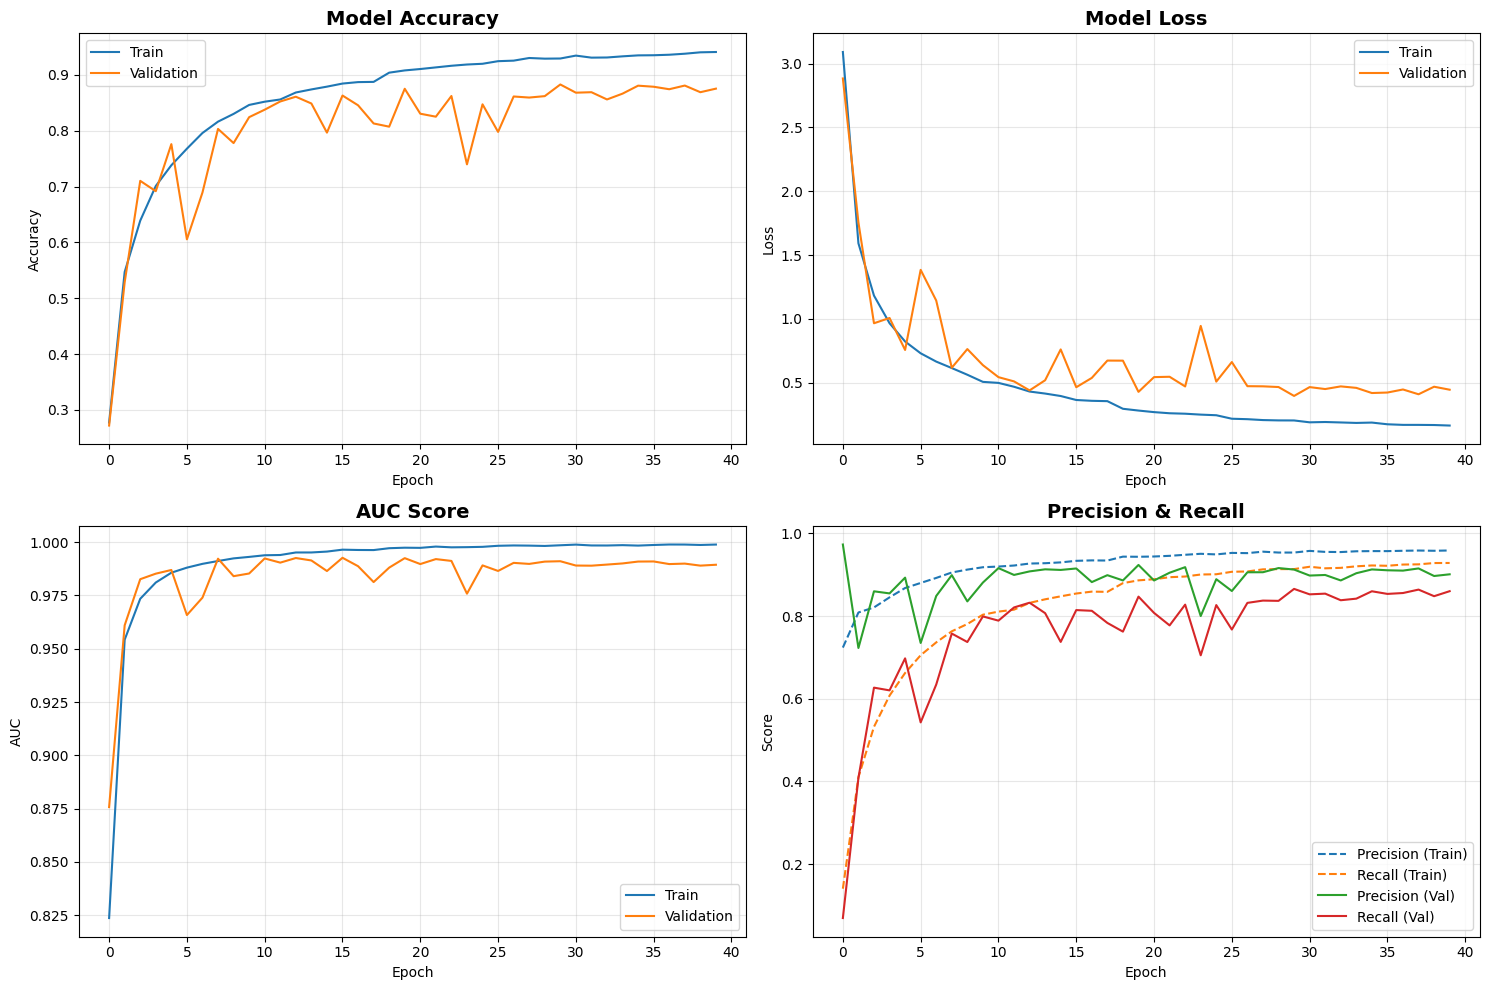

✅ Training curves saved to: training_curves.png


In [21]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy
axes[0, 0].plot(history.history['accuracy'], label='Train')
axes[0, 0].plot(history.history['val_accuracy'], label='Validation')
axes[0, 0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss
axes[0, 1].plot(history.history['loss'], label='Train')
axes[0, 1].plot(history.history['val_loss'], label='Validation')
axes[0, 1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# AUC
axes[1, 0].plot(history.history['auc'], label='Train')
axes[1, 0].plot(history.history['val_auc'], label='Validation')
axes[1, 0].set_title('AUC Score', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUC')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Precision & Recall
axes[1, 1].plot(history.history['precision'], label='Precision (Train)', linestyle='--')
axes[1, 1].plot(history.history['recall'], label='Recall (Train)', linestyle='--')
axes[1, 1].plot(history.history['val_precision'], label='Precision (Val)')
axes[1, 1].plot(history.history['val_recall'], label='Recall (Val)')
axes[1, 1].set_title('Precision & Recall', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_PATH, 'training_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Training curves saved to: training_curves.png")

---
## 4️⃣ EVALUATION: Test Set Performance

In [22]:
# Load best model
print("📂 Loading best model...")
best_model = keras.models.load_model(os.path.join(MODEL_SAVE_PATH, 'best_model.h5'))

# Evaluate on test set
print("\n🧪 Evaluating on test set...\n")
test_loss, test_acc, test_auc, test_precision, test_recall = best_model.evaluate(X_test, y_test, verbose=1)

# Calculate F1 score
test_f1 = 2 * (test_precision * test_recall) / (test_precision + test_recall)

print(f"\n{'='*60}")
print(f"📊 TEST SET RESULTS")
print(f"{'='*60}")
print(f"   Accuracy:  {test_acc*100:.2f}%")
print(f"   Precision: {test_precision*100:.2f}%")
print(f"   Recall:    {test_recall*100:.2f}%")
print(f"   F1-Score:  {test_f1*100:.2f}%")
print(f"   AUC:       {test_auc:.4f}")
print(f"   Loss:      {test_loss:.4f}")
print(f"{'='*60}\n")

# Save results
results = {
    'test_accuracy': float(test_acc),
    'test_precision': float(test_precision),
    'test_recall': float(test_recall),
    'test_f1': float(test_f1),
    'test_auc': float(test_auc),
    'test_loss': float(test_loss)
}

with open(os.path.join(MODEL_SAVE_PATH, 'test_results.json'), 'w') as f:
    json.dump(results, f, indent=2)

print(f"✅ Results saved to: test_results.json")

📂 Loading best model...



🧪 Evaluating on test set...

147/147 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - accuracy: 0.8928 - auc: 0.9920 - loss: 0.3786 - precision: 0.9210 - recall: 0.8736

📊 TEST SET RESULTS
   Accuracy:  89.28%
   Precision: 92.10%
   Recall:    87.36%
   F1-Score:  89.67%
   AUC:       0.9920
   Loss:      0.3786

✅ Results saved to: test_results.json


In [23]:
# Generate predictions for detailed analysis
print("🔮 Generating predictions...\n")
y_pred_probs = best_model.predict(X_test, verbose=1)
y_pred_classes = y_pred_probs.argmax(axis=1)
y_true_classes = y_test.argmax(axis=1)

# Classification report
print("\n📋 Per-Class Performance:\n")
report = classification_report(
    y_true_classes,
    y_pred_classes,
    target_names=label_encoder.classes_,
    digits=3
)
print(report)

# Save report
with open(os.path.join(MODEL_SAVE_PATH, 'classification_report.txt'), 'w') as f:
    f.write(report)

print(f"\n✅ Classification report saved")

🔮 Generating predictions...

147/147 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step

📋 Per-Class Performance:

                precision    recall  f1-score   support

     Adialer.C      1.000     0.982     0.991        56
      Adposhel      0.974     1.000     0.987        74
     Agent.FYI      1.000     1.000     1.000        54
     Allaple.A      0.953     0.943     0.948       669
     Allaple.L      0.976     0.917     0.946       362
 Alueron.gen!J      1.000     0.986     0.993        71
     Amonetize      1.000     0.973     0.986        74
        Androm      0.958     0.907     0.932        75
     Autorun.K      1.000     0.694     0.819        49
     BrowseFox      1.000     0.946     0.972        74
       C2LOP.P      0.857     0.906     0.881        53
   C2LOP.gen!g      0.967     0.819     0.887        72
CoinMinerXMRig      0.345     0.435     0.385        23
       Danabot      0.554     0.547     0.550        75
Dialplatform.B      1.000     1.000     1.000        64
    

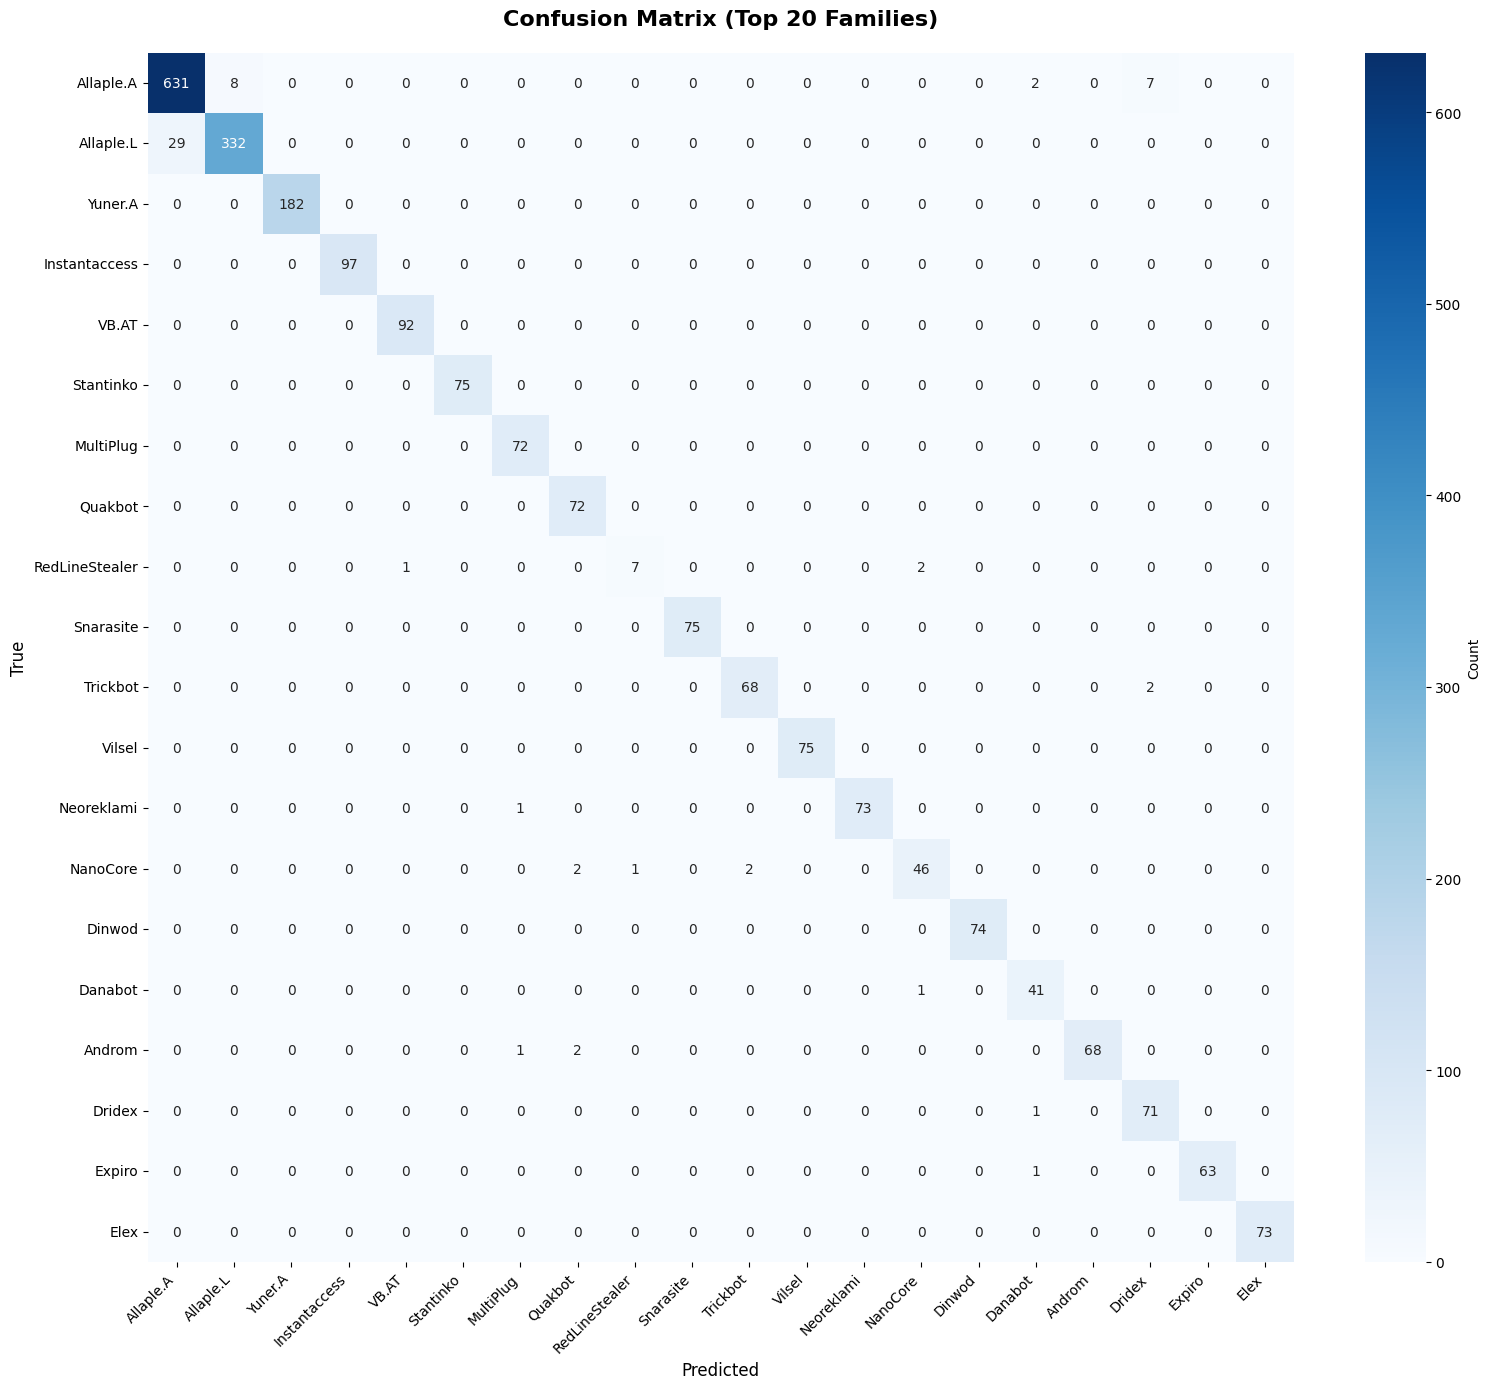

✅ Confusion matrix saved


In [24]:
# Confusion Matrix (simplified - top 20 classes)
from sklearn.metrics import confusion_matrix

# Get top 20 most frequent families
unique, counts = np.unique(y_true_classes, return_counts=True)
top_20_indices = counts.argsort()[-20:][::-1]
top_20_classes = unique[top_20_indices]

# Filter predictions for top 20 classes
mask = np.isin(y_true_classes, top_20_classes)
y_true_top20 = y_true_classes[mask]
y_pred_top20 = y_pred_classes[mask]

# Compute confusion matrix
cm = confusion_matrix(y_true_top20, y_pred_top20, labels=top_20_classes)

# Plot
plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[label_encoder.classes_[i] for i in top_20_classes],
    yticklabels=[label_encoder.classes_[i] for i in top_20_classes],
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix (Top 20 Families)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_PATH, 'confusion_matrix_top20.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Confusion matrix saved")

---
## 5️⃣ EXPLAINABILITY: Grad-CAM Heatmaps

**What this does:**
- Shows which parts of the malware image the model "looks at" when making predictions
- Helps analysts understand WHY a file was classified as a specific family

In [ ]:
# Grad-CAM implementation
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Generate Grad-CAM heatmap for a given image.

    Args:
        img_array: Input image (1, 128, 128, 1)
        model: Trained model
        last_conv_layer_name: Name of last conv layer
        pred_index: Class to visualize (if None, uses predicted class)

    Returns:
        heatmap: Grad-CAM heatmap (128, 128)
    """
    # Create a model that maps input → (conv output, predictions)
    grad_model = keras.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Compute gradient of predicted class w.r.t. conv layer output
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Gradient of class score w.r.t. feature map
    grads = tape.gradient(class_channel, conv_outputs)

    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weighted combination of feature maps
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize to [0, 1]
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


def display_gradcam(img, heatmap, alpha=0.4):
    """
    Overlay Grad-CAM heatmap on original image.
    """
    # Resize heatmap to match image size
    heatmap = np.uint8(255 * heatmap)
    heatmap = Image.fromarray(heatmap)
    heatmap = heatmap.resize((img.shape[1], img.shape[0]))
    heatmap = np.array(heatmap)

    # Apply colormap
    cmap = plt.get_cmap('jet')
    heatmap_colored = cmap(heatmap / 255.0)[:, :, :3]  # RGB

    # Convert grayscale to RGB
    img_rgb = np.repeat(img[:, :, 0:1], 3, axis=2)

    # Superimpose
    superimposed = heatmap_colored * alpha + img_rgb * (1 - alpha)
    return superimposed


print("✅ Grad-CAM functions defined")

In [ ]:
# Find the last convolutional layer in MobileNetV2
last_conv_layer_name = None
for layer in reversed(best_model.layers):
    if 'Conv' in layer.__class__.__name__:
        last_conv_layer_name = layer.name
        break

print(f"🔍 Last conv layer: {last_conv_layer_name}")

# Generate Grad-CAM for 12 random test samples
num_samples = 12
random_indices = np.random.choice(len(X_test), num_samples, replace=False)

fig, axes = plt.subplots(4, 6, figsize=(20, 14))
axes = axes.flatten()

print(f"\n🎨 Generating Grad-CAM visualizations for {num_samples} samples...\n")

for i, idx in enumerate(tqdm(random_indices)):
    img = X_test[idx:idx+1]
    true_class = y_true_classes[idx]
    pred_class = y_pred_classes[idx]

    # Generate heatmap
    heatmap = make_gradcam_heatmap(img, best_model, last_conv_layer_name, pred_index=pred_class)

    # Display original image
    axes[i*2].imshow(img[0, :, :, 0], cmap='gray')
    axes[i*2].set_title(f"Original\nTrue: {label_encoder.classes_[true_class]}\nPred: {label_encoder.classes_[pred_class]}",
                        fontsize=8)
    axes[i*2].axis('off')

    # Display Grad-CAM
    superimposed = display_gradcam(img[0], heatmap)
    axes[i*2+1].imshow(superimposed)
    axes[i*2+1].set_title(f"Grad-CAM\nConfidence: {y_pred_probs[idx, pred_class]*100:.1f}%", fontsize=8)
    axes[i*2+1].axis('off')

plt.suptitle('Grad-CAM Explainability: Where the Model "Looks"', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_SAVE_PATH, 'gradcam_examples.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Grad-CAM visualizations saved to: gradcam_examples.png")

---
## 📊 FINAL SUMMARY

In [25]:
print(f"\n{'='*70}")
print(f"🎉 FYP PIPELINE COMPLETE!")
print(f"{'='*70}\n")

print(f"📁 All outputs saved to: {MODEL_SAVE_PATH}\n")

print(f"📂 Generated Files:")
print(f"   ✅ best_model.h5 - Trained model (ready for deployment)")
print(f"   ✅ label_encoder.pkl - Class label mapping")
print(f"   ✅ training_log.csv - Full training history")
print(f"   ✅ training_curves.png - Accuracy/loss plots")
print(f"   ✅ test_results.json - Final test metrics")
print(f"   ✅ classification_report.txt - Per-class performance")
print(f"   ✅ confusion_matrix_top20.png - Confusion matrix")
print(f"   ✅ gradcam_examples.png - Explainability visualizations\n")

print(f"📊 Final Test Results:")
print(f"   🎯 Accuracy:  {test_acc*100:.2f}%")
print(f"   🎯 Precision: {test_precision*100:.2f}%")
print(f"   🎯 Recall:    {test_recall*100:.2f}%")
print(f"   🎯 F1-Score:  {test_f1*100:.2f}%")
print(f"   🎯 AUC:       {test_auc:.4f}\n")

print(f"🚀 Next Steps:")
print(f"   1. Download all files from {MODEL_SAVE_PATH}")
print(f"   2. Integrate with Flower federated learning framework")
print(f"   3. Build Streamlit dashboard for monitoring")
print(f"   4. Coordinate with EMBER partner for FedMD integration\n")

print(f"{'='*70}\n")

print(f"💡 Pro Tips:")
print(f"   - Model is saved in Google Drive (persistent)")
print(f"   - To resume training: Load 'best_model.h5' and continue")



🎉 FYP PIPELINE COMPLETE!

📁 All outputs saved to: /content/drive/MyDrive/FYP_Models

📂 Generated Files:
   ✅ best_model.h5 - Trained model (ready for deployment)
   ✅ label_encoder.pkl - Class label mapping
   ✅ training_log.csv - Full training history
   ✅ training_curves.png - Accuracy/loss plots
   ✅ test_results.json - Final test metrics
   ✅ classification_report.txt - Per-class performance
   ✅ confusion_matrix_top20.png - Confusion matrix
   ✅ gradcam_examples.png - Explainability visualizations

📊 Final Test Results:
   🎯 Accuracy:  89.28%
   🎯 Precision: 92.10%
   🎯 Recall:    87.36%
   🎯 F1-Score:  89.67%
   🎯 AUC:       0.9920

🚀 Next Steps:
   1. Download all files from /content/drive/MyDrive/FYP_Models
   2. Integrate with Flower federated learning framework
   3. Build Streamlit dashboard for monitoring
   4. Coordinate with EMBER partner for FedMD integration


💡 Pro Tips:
   - Model is saved in Google Drive (persistent)
   - To resume training: Load 'best_model.h5' and